# 1.2

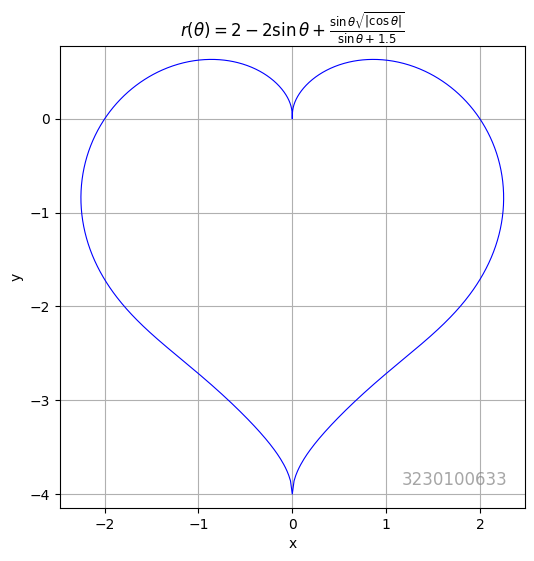

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# 参数
n = np.arange(0, 1280)
theta = (2 * np.pi * n) / 1280

# 计算 r(theta)
sin_t = np.sin(theta)
cos_t = np.cos(theta)
r = 2 - 2*sin_t + (sin_t * np.sqrt(np.abs(cos_t))) / (sin_t + 1.5)

# 直角坐标
x = r * cos_t
y = r * sin_t

# 绘图
plt.figure(figsize=(6,6))
plt.plot(x, y, 'b-', linewidth=0.8)
plt.axis('equal')
plt.title(r'$r(\theta) = 2 - 2\sin\theta + \frac{\sin\theta\sqrt{|\cos\theta|}}{\sin\theta+1.5}$')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True)

# 添加学号水印（请替换为您的实际学号）
student_id = "3230100633"   # 改成你的学号
plt.text(0.85, 0.05, student_id, transform=plt.gca().transAxes,
         fontsize=12, color='gray', alpha=0.7, ha='center')

plt.show()

# 1.3


a(0) = -0.00 + -0.70i
a(1) = 1.80 + -0.00i


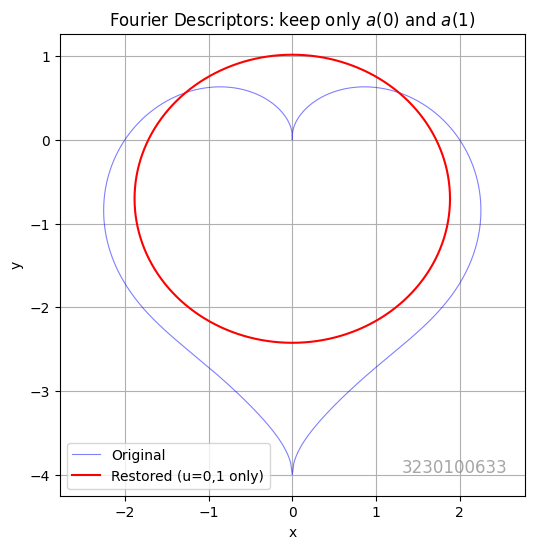

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# 1. 生成第2题的边界点
n = np.arange(0, 1280)
theta = (2 * np.pi * n) / 1280

sin_t = np.sin(theta)
cos_t = np.cos(theta)
r = 2 - 2*sin_t + (sin_t * np.sqrt(np.abs(cos_t))) / (sin_t + 1.5)

x = r * cos_t
y = r * sin_t

# 2. 转为复数序列
z = x + 1j * y
N = len(z)

# 3. 傅里叶变换
a = np.fft.fft(z) / N   # 归一化

# 4. 仅保留 a(0) 和 a(1)，其余置零
a_restricted = np.zeros_like(a, dtype=complex)
a_restricted[0] = a[0]
a_restricted[1] = a[1]
# 对于实序列重构，负频率对应共轭，但这里直接保留正频率，重构时会丢失能量。
# 更严谨做法：保留 a[0], a[1] 和 a[N-1] (即负频率)
# 否则轨迹不闭合/不实数。因此我们保留 a[0], a[1], a[N-1]
a_restricted[N-1] = a[N-1]

# 5. 逆变换得到新边界
z_restricted = np.fft.ifft(a_restricted * N)  # 因为之前 a = fft/N
print(f"a(0) = {a[0].real:.2f} + {a[0].imag:.2f}i")
print(f"a(1) = {a[1].real:.2f} + {a[1].imag:.2f}i")

# 6. 提取坐标
x_new = np.real(z_restricted)
y_new = np.imag(z_restricted)

# 7. 绘图
plt.figure(figsize=(6,6))
plt.plot(x, y, 'b-', linewidth=0.8, alpha=0.5, label='Original')
plt.plot(x_new, y_new, 'r-', linewidth=1.5, label='Restored (u=0,1 only)')
plt.axis('equal')
plt.title(r'Fourier Descriptors: keep only $a(0)$ and $a(1)$')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)

student_id = "3230100633"  # 替换为你的学号
plt.text(0.85, 0.05, student_id, transform=plt.gca().transAxes,
         fontsize=12, color='gray', alpha=0.7, ha='center')
plt.show()

# 1.4

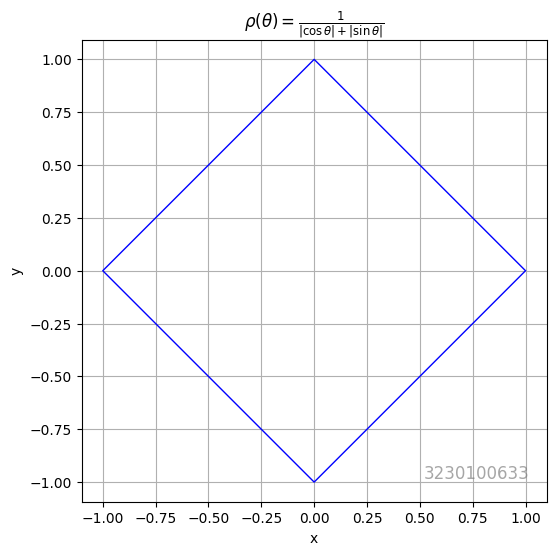

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# 参数
n = np.arange(0, 1280)
theta = (2 * np.pi * n) / 1280

# 计算 rho(theta)
cos_t = np.cos(theta)
sin_t = np.sin(theta)
rho = 1.0 / (np.abs(cos_t) + np.abs(sin_t))

# 直角坐标
x = rho * cos_t
y = rho * sin_t

# 绘图
plt.figure(figsize=(6,6))
plt.plot(x, y, 'b-', linewidth=1)
plt.axis('equal')
plt.title(r'$\rho(\theta) = \frac{1}{|\cos\theta| + |\sin\theta|}$')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True)

# 学号水印（请替换）
student_id = "3230100633"
plt.text(0.85, 0.05, student_id, transform=plt.gca().transAxes,
         fontsize=12, color='gray', alpha=0.7, ha='center')

plt.show()

a(0) = -0.00 + 0.00i
a(1) = 0.79 + -0.00i


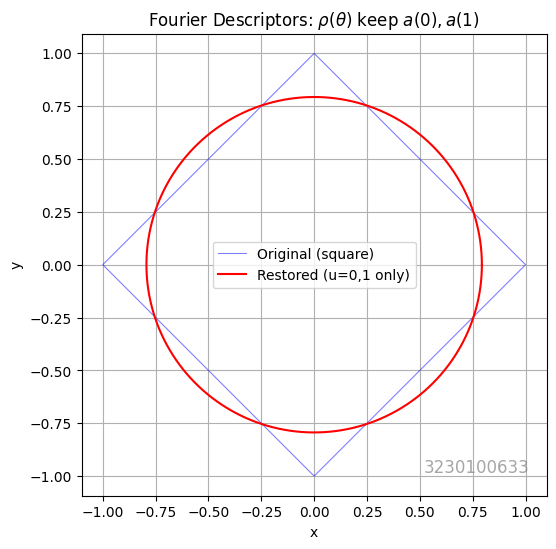

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# 生成边界点
n = np.arange(0, 1280)
theta = (2 * np.pi * n) / 1280

cos_t = np.cos(theta)
sin_t = np.sin(theta)
rho = 1.0 / (np.abs(cos_t) + np.abs(sin_t))

x = rho * cos_t
y = rho * sin_t

# 转为复数
z = x + 1j * y
N = len(z)

# 傅里叶变换
a = np.fft.fft(z) / N

# 仅保留 a(0), a(1), a(N-1)
a_restricted = np.zeros_like(a, dtype=complex)
a_restricted[0] = a[0]
a_restricted[1] = a[1]
a_restricted[N-1] = a[N-1]

# 逆变换
z_restricted = np.fft.ifft(a_restricted * N)

x_new = np.real(z_restricted)
y_new = np.imag(z_restricted)

# 输出 a(0), a(1) 保留两位小数
print(f"a(0) = {a[0].real:.2f} + {a[0].imag:.2f}i")
print(f"a(1) = {a[1].real:.2f} + {a[1].imag:.2f}i")

# 绘图对比
plt.figure(figsize=(6,6))
plt.plot(x, y, 'b-', linewidth=0.8, alpha=0.5, label='Original (square)')
plt.plot(x_new, y_new, 'r-', linewidth=1.5, label='Restored (u=0,1 only)')
plt.axis('equal')
plt.title(r'Fourier Descriptors: $\rho(\theta)$ keep $a(0),a(1)$')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)

student_id = "3230100633"
plt.text(0.85, 0.05, student_id, transform=plt.gca().transAxes,
         fontsize=12, color='gray', alpha=0.7, ha='center')
plt.show()

# 2.2

In [2]:
import numpy as np

# 初始图像 I_0
I = np.array([
    [3, 1, 0, 0, 2],
    [1, 0, 1, 1, 0],
    [0, 2, 0, 3, 1],
    [1, 2, 1, 0, 0],
    [0, 0, 2, 3, 1]
], dtype=np.float64)

def circular_diffuse(img, iterations=1):
    """
    对图像进行循环卷积热扩散。
    每次迭代用 3x3 均值滤波（循环边界）。
    """
    kernel = np.ones((3, 3)) / 9.0
    result = img.copy()
    for _ in range(iterations):
        # 使用 circular padding 的卷积
        # 先用 np.pad 做循环填充，然后用 valid 卷积
        padded = np.pad(result, pad_width=1, mode='wrap')
        new = np.zeros_like(result)
        for i in range(result.shape[0]):
            for j in range(result.shape[1]):
                new[i, j] = np.sum(padded[i:i+3, j:j+3] * kernel)
        result = new
    return result

# 计算 I_1（一次迭代）
I1 = circular_diffuse(I, iterations=1)

print("I_1 (一次迭代后):")
print(f"\n总亮度: {I1.sum():.6f}")
print(f"原图总亮度: {I.sum():.6f}")
print(np.round(I1, 4))

# 看看更多次迭代
print("\n---多次迭代---")
for t in [1, 5, 10, 50, 200]:
    It = circular_diffuse(I, iterations=t)
    print(f"I_{t}: 范围 [{It.min():.4f}, {It.max():.4f}], 均值 = {It.mean():.4f}")

I_1 (一次迭代后):

总亮度: 25.000000
原图总亮度: 25.000000
[[0.8889 0.8889 0.8889 1.1111 1.2222]
 [1.1111 0.8889 0.8889 0.8889 1.2222]
 [0.7778 0.8889 1.1111 0.7778 0.7778]
 [0.7778 0.8889 1.4444 1.2222 1.    ]
 [1.1111 1.1111 1.     1.     1.1111]]

---多次迭代---
I_1: 范围 [0.7778, 1.4444], 均值 = 1.0000
I_5: 范围 [0.9896, 1.0117], 均值 = 1.0000
I_10: 范围 [0.9996, 1.0005], 均值 = 1.0000
I_50: 范围 [1.0000, 1.0000], 均值 = 1.0000
I_200: 范围 [1.0000, 1.0000], 均值 = 1.0000
